Dataset Fashion Ecommerce User DataSet sadrži podatke o korisnicima i njihovim aktivnostima u online prodavnici modne odeće.

Tipično obuhvata informacije kao što su:
- demografski podaci korisnika (pol, starost, lokacija),
- ponašanje korisnika (broj pregleda, kupovina, vreme provedeno na sajtu),
- finansijski podaci (potrošnja, prosečna vrednost porudžbine),
- preferencije proizvoda ili kategorija.

Ovaj skup podataka je pogodan za analizu korisničkog ponašanja i segmentaciju kupaca u e-commerce sistemima.

Cilj klasterizacije je da:
- grupišemo korisnike sa sličnim ponašanjem i karakteristikama
- otkrijemo skrivene obrasce u podacima
- identifikujemo različite tipove kupaca


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler 

# Priprema i deskriptivna analiza

## Prikaz podataka

In [3]:
data_set = pd.read_csv("ds1.csv")

print(data_set)

            identifierHash  type     country language  socialNbFollowers  \
0     -7279641312655250028  user  Etats-Unis       en                  3   
1     -1456013578740053406  user   Allemagne       de                  3   
2      9006282053848196165  user       Suède       en                  3   
3     -7154634866120535654  user     Turquie       en                  3   
4      2858299215060733023  user      France       en                  3   
...                    ...   ...         ...      ...                ...   
98908 -5324380437900495747  user  Etats-Unis       fr                  3   
98909 -5607668753771114442  user      France       fr                  3   
98910   350630276238833248  user    Belgique       en                  3   
98911  2006580738726207028  user      Italie       it                  3   
98912 -7621316584087253691  user      Guinée       fr                  3   

       socialNbFollows  socialProductsLiked  productsListed  productsSold  \
0         

In [4]:
data_set.info()
data_set.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98913 entries, 0 to 98912
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   identifierHash       98913 non-null  int64  
 1   type                 98913 non-null  object 
 2   country              98913 non-null  object 
 3   language             98913 non-null  object 
 4   socialNbFollowers    98913 non-null  int64  
 5   socialNbFollows      98913 non-null  int64  
 6   socialProductsLiked  98913 non-null  int64  
 7   productsListed       98913 non-null  int64  
 8   productsSold         98913 non-null  int64  
 9   productsPassRate     98913 non-null  float64
 10  productsWished       98913 non-null  int64  
 11  productsBought       98913 non-null  int64  
 12  gender               98913 non-null  object 
 13  civilityGenderId     98913 non-null  int64  
 14  civilityTitle        98913 non-null  object 
 15  hasAnyApp            98913 non-null 

,identifierHash,socialNbFollowers,socialNbFollows,socialProductsLiked,productsListed,productsSold,productsPassRate,productsWished,productsBought,civilityGenderId,daysSinceLastLogin,seniority,seniorityAsMonths,seniorityAsYears
count,9.891300e+04,98913.000000,98913.000000,98913.000000,98913.000000,98913.000000,98913.000000,98913.000000,98913.000000,98913.000000,98913.000000,98913.000000,98913.000000,98913.000000
mean,-6.692039e+15,3.432269,8.425677,4.420743,0.093304,0.121592,0.812303,1.562595,0.171929,1.773993,655.732310,3063.771870,102.125583,8.510424
std,5.330807e+18,3.882383,52.839572,181.030569,2.050144,2.126895,8.500205,25.192793,2.332266,0.428679,7407.430369,168.298621,5.609735,0.467863
min,-9.223101e+18,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,11.000000,2852.000000,95.070000,7.920000
25%,-4.622895e+18,3.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,572.000000,2857.000000,95.230000,7.940000
50%,-1.337989e+15,3.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,694.000000,3196.000000,106.530000,8.880000
75%,4.616388e+18,3.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,702.000000,3201.000000,106.700000,8.890000
max,9.223331e+18,744.000000,13764.000000,51671.000000,244.000000,174.000000,100.000000,2635.000000,405.000000,3.000000,737028.000000,3205.000000,106.830000,8.900000


## Provera nedostajućih vrednosti i duplikata

In [5]:
print(data_set.isnull().sum())

identifierHash         0
type                   0
country                0
language               0
socialNbFollowers      0
socialNbFollows        0
socialProductsLiked    0
productsListed         0
productsSold           0
productsPassRate       0
productsWished         0
productsBought         0
gender                 0
civilityGenderId       0
civilityTitle          0
hasAnyApp              0
hasAndroidApp          0
hasIosApp              0
hasProfilePicture      0
daysSinceLastLogin     0
seniority              0
seniorityAsMonths      0
seniorityAsYears       0
countryCode            0
dtype: int64


Nemamo null vrednosti.

In [6]:
duplicates = data_set.duplicated()
print(data_set[duplicates])
print(f"Broj duplikata:{duplicates.sum()}")

Empty DataFrame
Columns: [identifierHash, type, country, language, socialNbFollowers, socialNbFollows, socialProductsLiked, productsListed, productsSold, productsPassRate, productsWished, productsBought, gender, civilityGenderId, civilityTitle, hasAnyApp, hasAndroidApp, hasIosApp, hasProfilePicture, daysSinceLastLogin, seniority, seniorityAsMonths, seniorityAsYears, countryCode]
Index: []

[0 rows x 24 columns]
Broj duplikata:0


Nemamo duplikate.

## Uklanjanje nepotrebnih kolona

U cilju pripreme podataka za klasterizaciju uklonjeni su atributi koji nemaju informativnu vrednost za proces grupisanja korisnika. Atribut _identifierHash_ je uklonjen jer predstavlja jedinstveni identifikator bez analitičkog značaja. Takođe je uklonjena kolona _type_, budući da sadrži samo jednu vrednost i ne doprinosi varijabilnosti podataka.

### Uklanjanje kolone _identifierHash_

In [7]:
data_set = data_set.drop(columns=['identifierHash'])
data_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98913 entries, 0 to 98912
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   type                 98913 non-null  object 
 1   country              98913 non-null  object 
 2   language             98913 non-null  object 
 3   socialNbFollowers    98913 non-null  int64  
 4   socialNbFollows      98913 non-null  int64  
 5   socialProductsLiked  98913 non-null  int64  
 6   productsListed       98913 non-null  int64  
 7   productsSold         98913 non-null  int64  
 8   productsPassRate     98913 non-null  float64
 9   productsWished       98913 non-null  int64  
 10  productsBought       98913 non-null  int64  
 11  gender               98913 non-null  object 
 12  civilityGenderId     98913 non-null  int64  
 13  civilityTitle        98913 non-null  object 
 14  hasAnyApp            98913 non-null  bool   
 15  hasAndroidApp        98913 non-null 

### Uklanjanje kolone _type_

In [8]:
data_set['type'].value_counts()

type
user    98913
Name: count, dtype: int64

In [9]:
data_set = data_set.drop(columns=['type'])

### Analiza _country_ kolone

In [10]:
data_set['country'].nunique()

200

In [11]:
data_set['country'].value_counts().head(10)

country
France         25135
Etats-Unis     20602
Royaume-Uni    11310
Italie          8015
Allemagne       6567
Espagne         5706
Australie       2719
Danemark        1892
Suède           1826
Belgique        1666
Name: count, dtype: int64

Atribut _country_ je uklonjen zbog velikog broja jedinstvenih kategorija (200), što bi dovelo do značajnog povećanja dimenzionalnosti prilikom enkodiranja.

In [12]:
data_set = data_set.drop(columns=['country'])

In [13]:
data_set['language'].nunique()

5

In [14]:
data_set['language'].value_counts().head(10)

language
en    51564
fr    26372
it     7766
de     7178
es     6033
Name: count, dtype: int64

In [15]:
pd.crosstab(data_set['language'], data_set['countryCode'])


countryCode,ad,ae,af,ag,ai,al,am,an,ao,aq,...,ve,vg,vi,vn,vu,ws,yt,za,zm,zw
language,,,,,,,,,,,,,,,,,,,,,
de,0,1,2,0,0,2,0,0,1,0,...,0,1,1,2,0,0,0,0,0,0
en,4,121,4,0,0,28,16,1,4,0,...,4,2,2,60,1,1,0,83,1,4
es,5,3,0,0,0,0,0,0,0,0,...,10,0,0,0,0,0,0,0,0,0
fr,0,6,4,3,1,2,0,0,0,1,...,0,0,0,2,0,0,1,0,0,1
it,0,0,0,0,1,5,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


Analizom kontingencijske tabele između atributa _language_ i _countryCode_ uočeno je da više država deli isti jezik, dok atribut _countryCode_ sadrži znatno veći broj kategorija. Stoga je zadržan atribut _language_ kao informativniji i kompaktniji prikaz geografskog porekla korisnika.

In [16]:
data_set['countryCode'].nunique()

199

In [17]:
data_set = data_set.drop(columns=['countryCode'])

# Enkodiranje podataka

## Enkodiranje _language_ kolone

In [18]:

ohe = OneHotEncoder(sparse_output=False)

language_encoded = ohe.fit_transform(data_set[['language']])

language_cols = ohe.get_feature_names_out(['language'])
data_set_language = pd.DataFrame(language_encoded, columns=language_cols, index=data_set.index)

data_set = pd.concat([data_set.drop(columns=['language']), data_set_language], axis=1)

print(data_set_language.head())


   language_de  language_en  language_es  language_fr  language_it
0          0.0          1.0          0.0          0.0          0.0
1          1.0          0.0          0.0          0.0          0.0
2          0.0          1.0          0.0          0.0          0.0
3          0.0          1.0          0.0          0.0          0.0
4          0.0          1.0          0.0          0.0          0.0


## Enkodiranje _gender_ kolone

In [19]:
ohe_gender = OneHotEncoder(sparse_output=False)
gender_encoded = ohe_gender.fit_transform(data_set[['gender']])
gender_cols = ohe_gender.get_feature_names_out(['gender'])
data_set_gender = pd.DataFrame(gender_encoded, columns=gender_cols, index=data_set.index)

data_set = pd.concat([data_set.drop(columns=['gender']), data_set_gender], axis=1)
print(data_set_gender.head())


   gender_F  gender_M
0       1.0       0.0
1       1.0       0.0
2       0.0       1.0
3       1.0       0.0
4       0.0       1.0


In [20]:
data_set = data_set.drop(columns=['civilityTitle'])
data_set = data_set.drop(columns=['civilityGenderId'])

In [21]:
from sklearn.preprocessing import LabelEncoder

bool_cols = ['hasAnyApp', 'hasAndroidApp', 'hasIosApp', 'hasProfilePicture']

le = LabelEncoder()

for col in bool_cols:
    data_set[col] = le.fit_transform(data_set[col])

print(data_set[bool_cols].head())

   hasAnyApp  hasAndroidApp  hasIosApp  hasProfilePicture
0          0              0          0                  1
1          0              0          0                  1
2          1              0          1                  1
3          0              0          0                  1
4          1              0          1                  1


# Deskriptivna analiza

Vizualizacija raspodele numeričkih kolona.
Ovo pomaže u identifikaciji outlier-a i razumevanju distribucije podataka.

 ## Prikaz pomoću histograma.

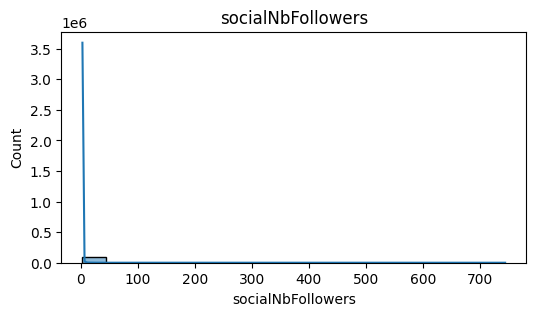

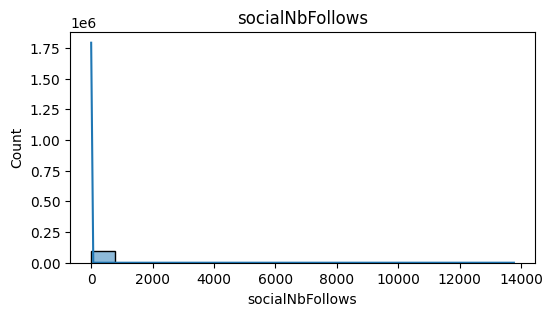

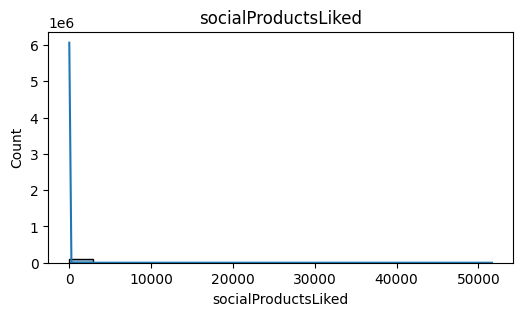

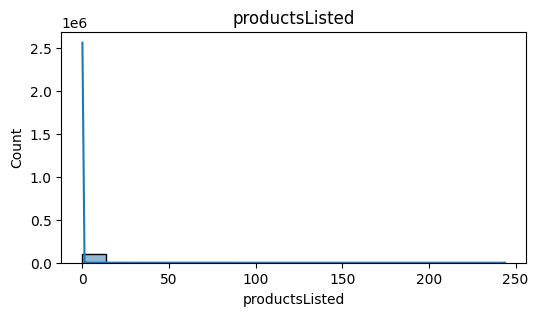

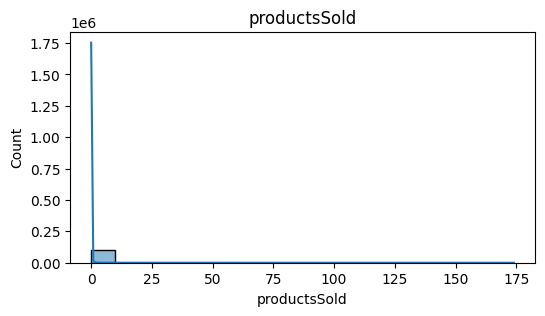

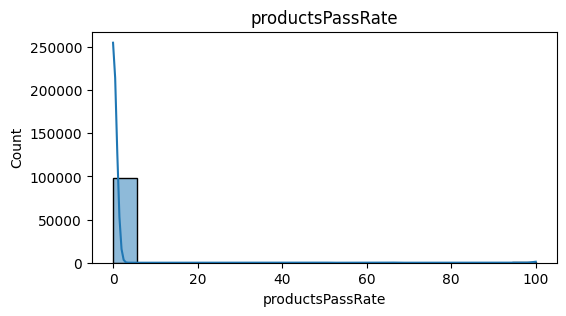

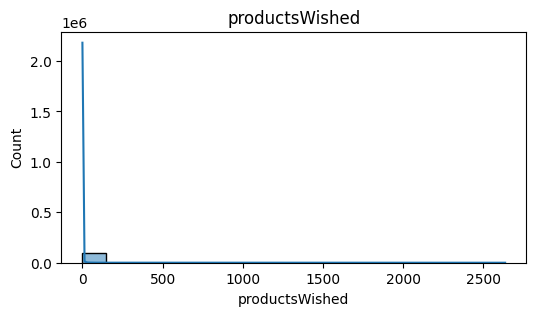

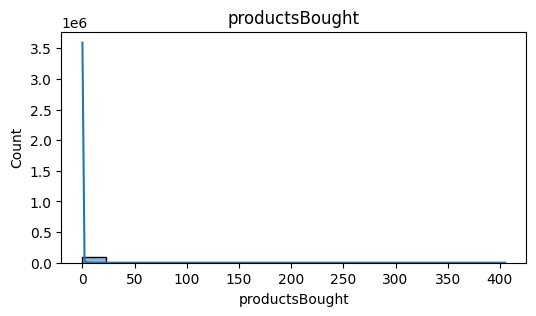

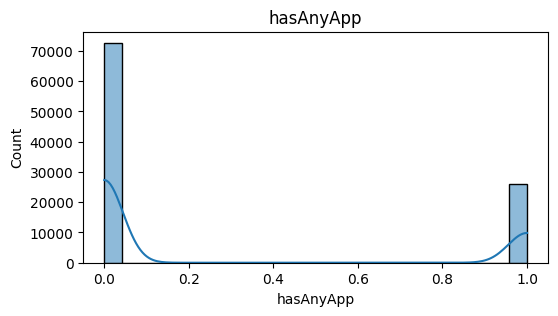

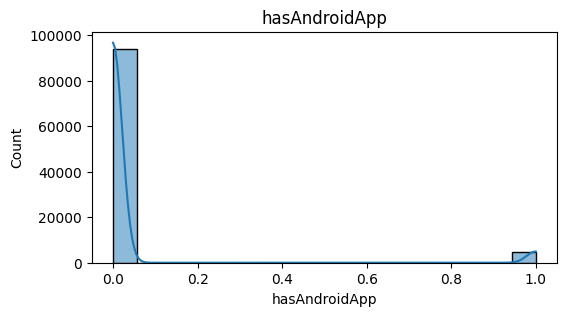

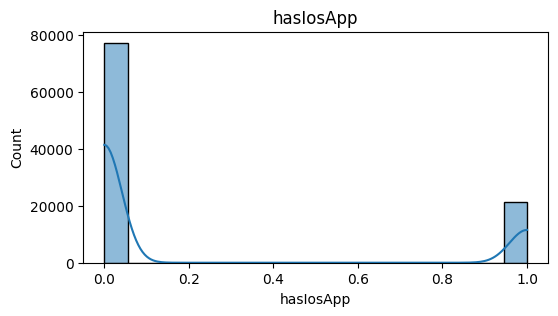

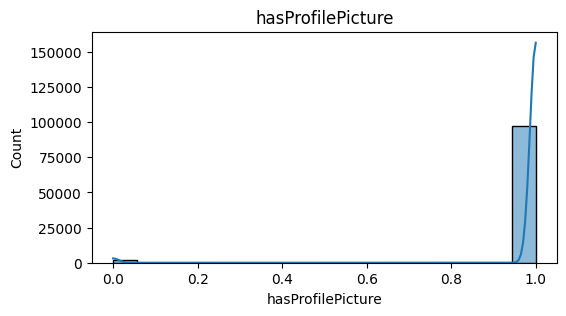

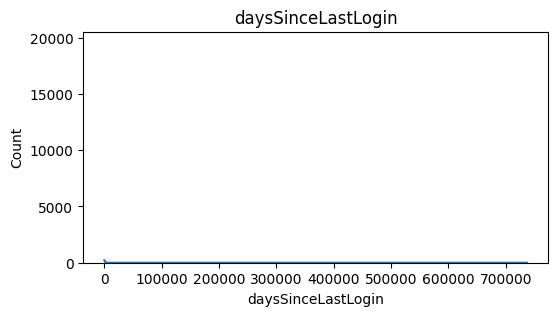

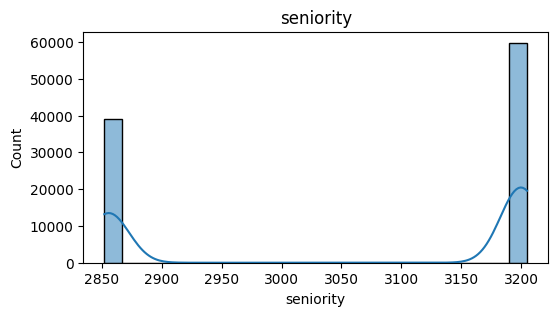

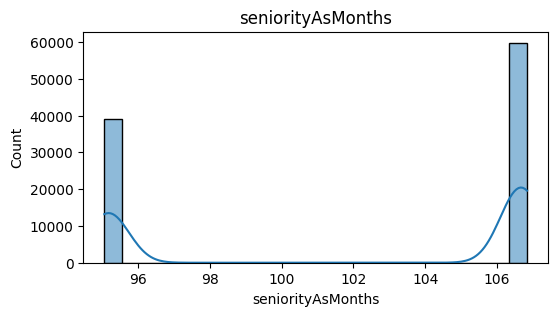

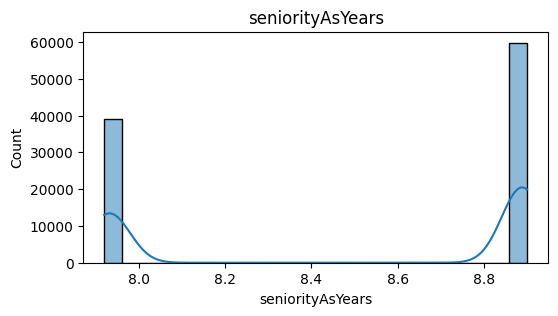

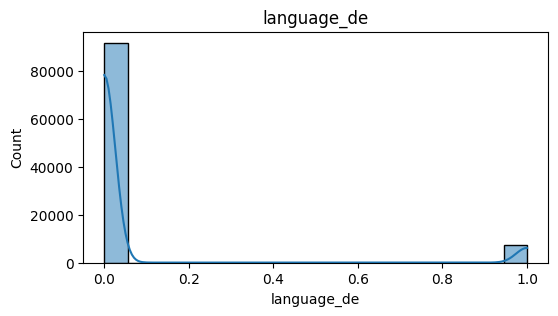

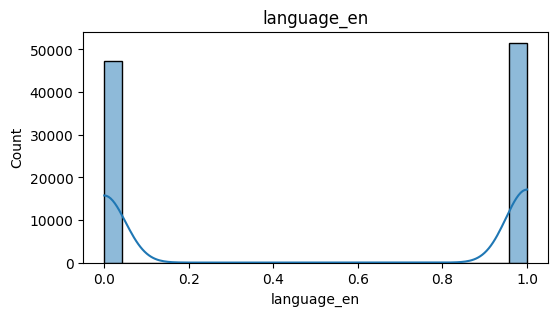

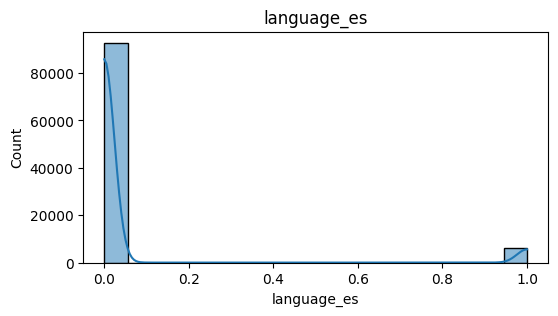

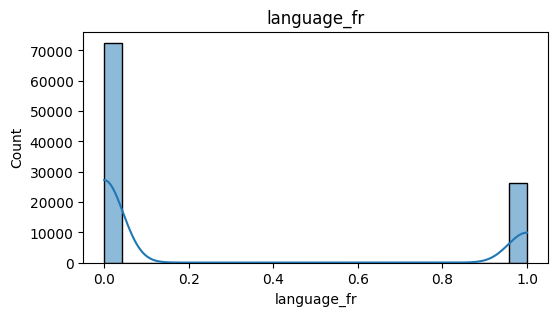

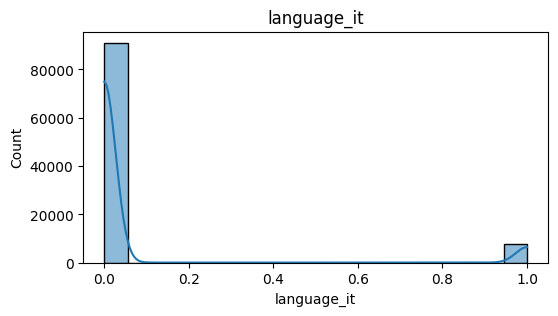

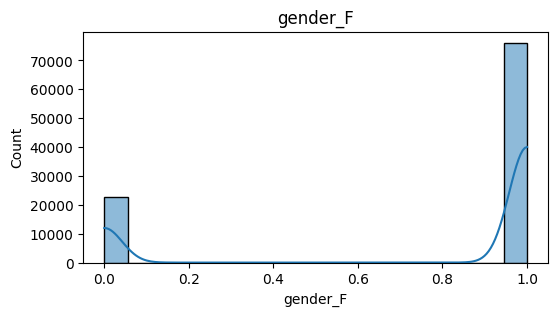

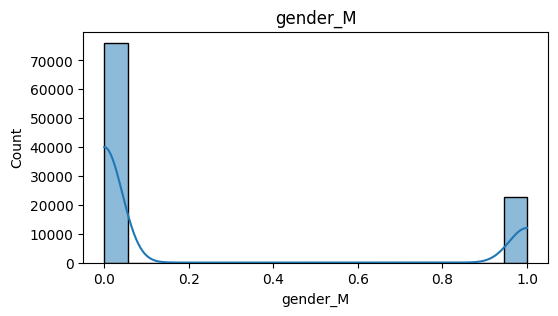

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = data_set.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(data_set[col], kde=True)
    plt.title(col)
    plt.show()


## Prikaz pomoću boxplotova.

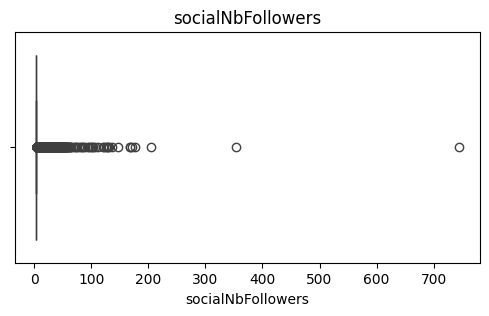

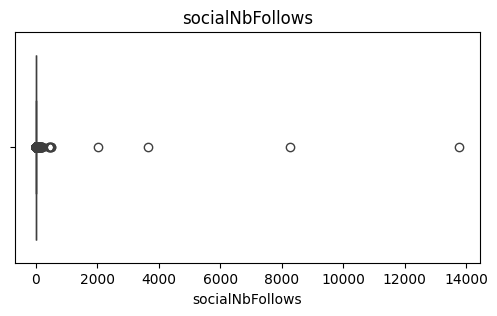

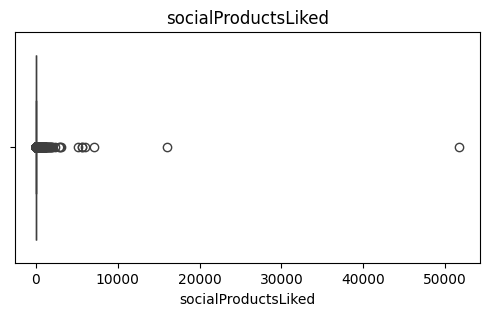

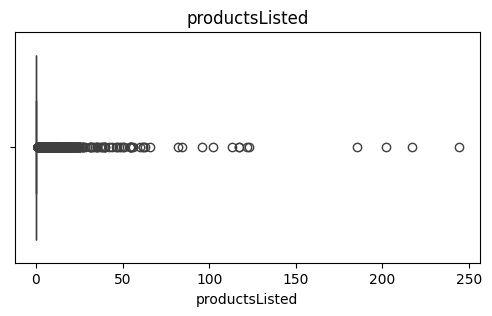

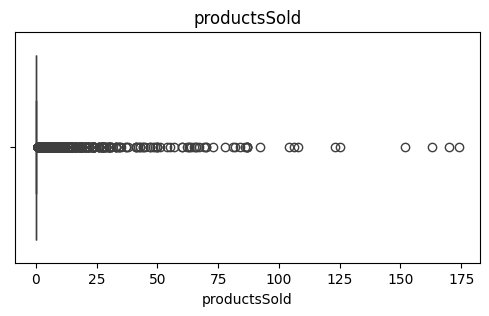

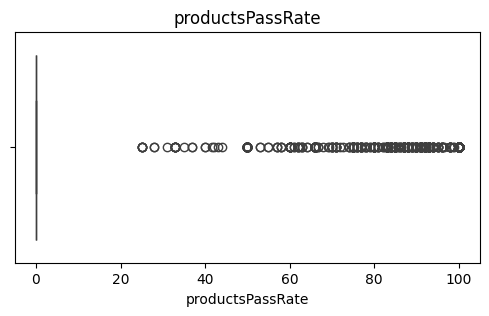

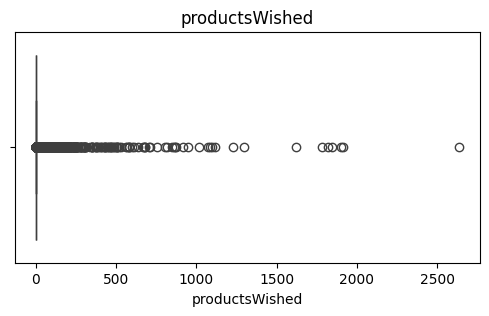

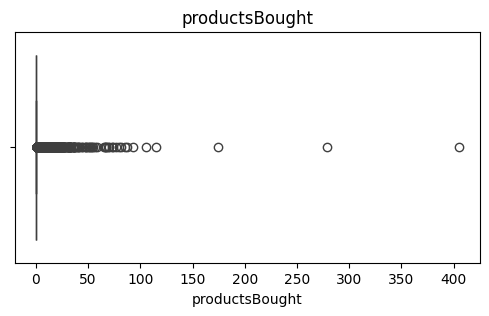

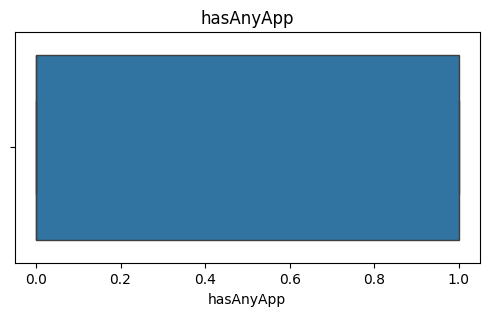

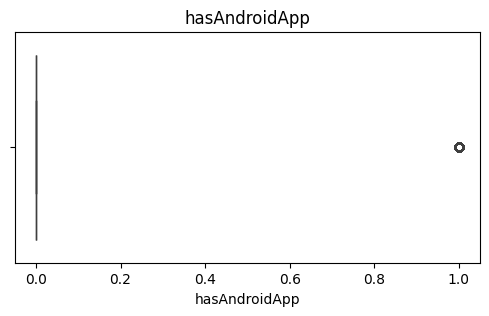

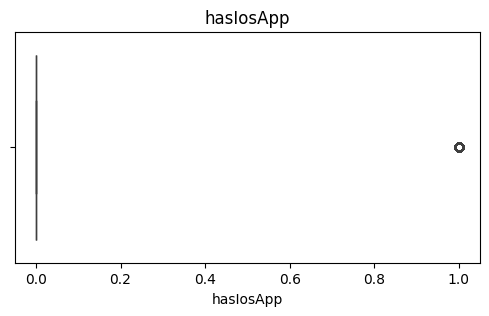

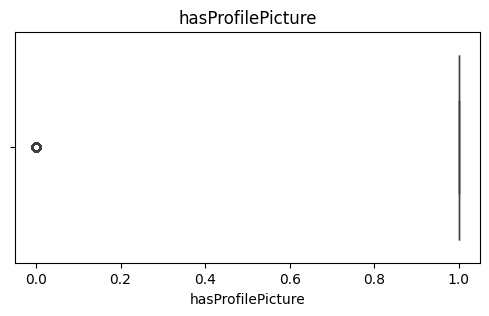

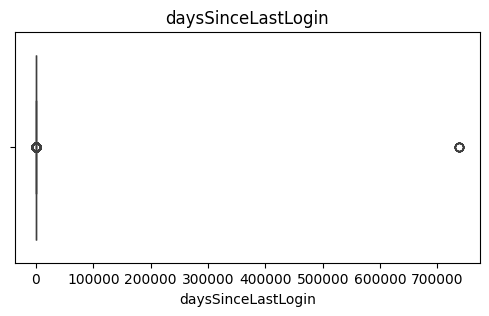

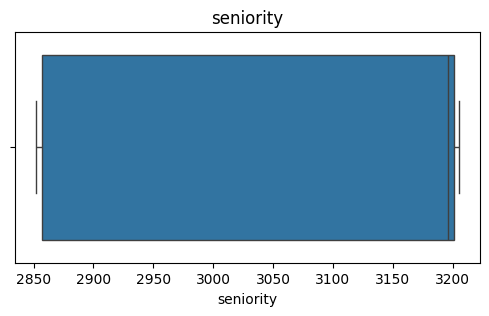

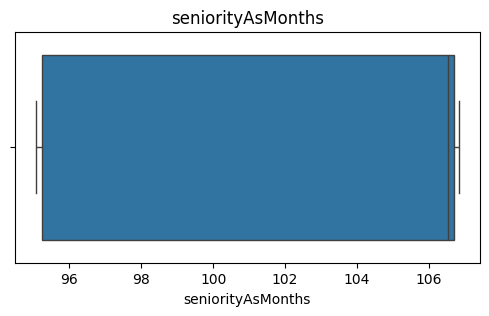

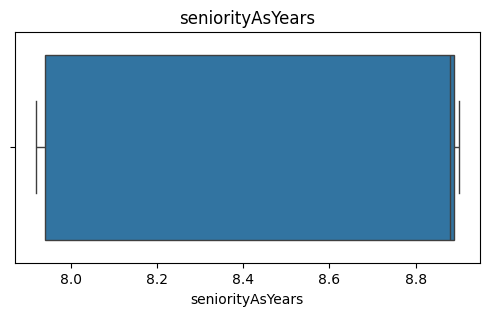

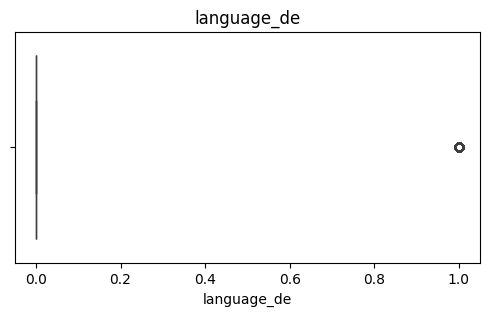

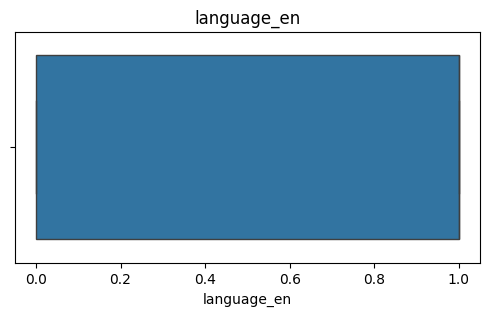

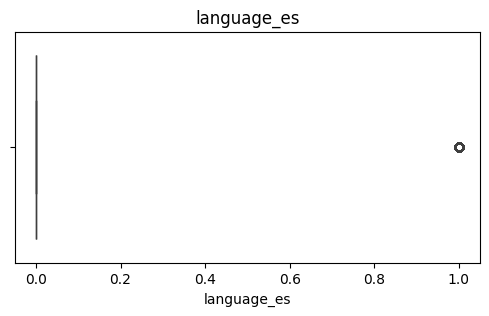

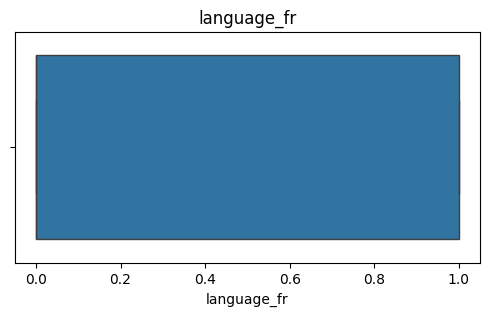

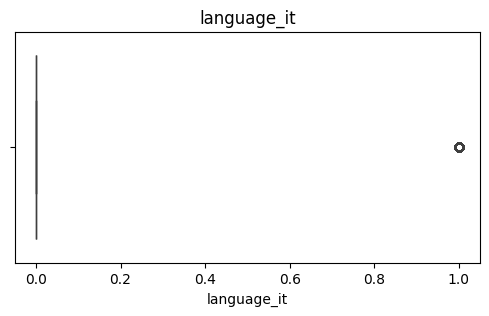

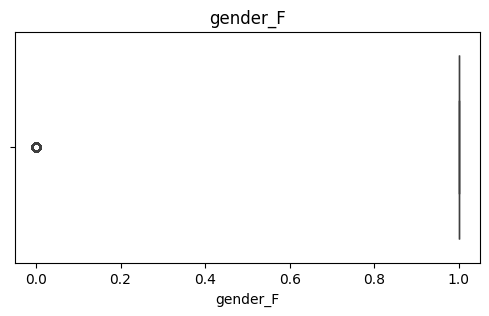

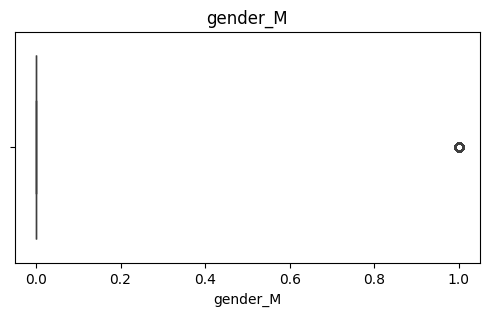

In [23]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=data_set[col])
    plt.title(col)
    plt.show()


## Poređenje transformacija K means algoritmom, koju metodu izabrati za uklanjanje outliera

In [24]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

df_original = data_set.copy()

num_cols = df_original.select_dtypes(include=['int64', 'float64']).columns


### K-Means BEZ obrade

In [25]:
df1 = df_original[num_cols].copy()

scaler1 = StandardScaler()
X1 = scaler1.fit_transform(df1)

kmeans1 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels1 = kmeans1.fit_predict(X1)

score1 = silhouette_score(X1, labels1)
print("Silhouette score (bez obrade):", score1)

Silhouette score (bez obrade): 0.2692956527481972


### K-Means sa IQR metodom

In [26]:
df2 = df_original[num_cols].copy()

for col in df2.columns:
    Q1 = df2[col].quantile(0.25)
    Q3 = df2[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df2 = df2[(df2[col] >= lower) & (df2[col] <= upper)]

scaler2 = StandardScaler()
X2 = scaler2.fit_transform(df2)

kmeans2 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels2 = kmeans2.fit_predict(X2)

score2 = silhouette_score(X2, labels2)
print("Silhouette score (IQR):", score2)

Silhouette score (IQR): 0.6993249395349301


### K-Means sa log transformacijom

In [27]:
df3 = df_original[num_cols].copy()

for col in df3.columns:
    if (df3[col] >= 0).all():
        df3[col] = np.log1p(df3[col])

scaler3 = StandardScaler()
X3 = scaler3.fit_transform(df3)

kmeans3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels3 = kmeans3.fit_predict(X3)

score3 = silhouette_score(X3, labels3)
print("Silhouette score (log transformacija):", score3)

KeyboardInterrupt: 

In [ ]:
print("=== POREĐENJE ===")
print(f"Bez obrade: {score1}")
print(f"IQR metoda: {score2}")
print(f"Log transformacija: {score3}")

=== POREĐENJE ===
Bez obrade: 0.2692956527481972
IQR metoda: 0.6993249395349301
Log transformacija: 0.22847897959960173


Rezultati pokazuju da prisustvo ekstremnih vrednosti značajno utiče na kvalitet klasterizacije. Nakon primene IQR metode za uklanjanje outlier-a, Silhouette score se povećao sa 0.27 na 0.67, što ukazuje na znatno bolje definisane i razdvojene klastere. Logaritamska transformacija nije dovela do značajnog poboljšanja, što sugeriše da ekstremne vrednosti imaju snažan uticaj na strukturu podataka.

## Koorelaciona matrica

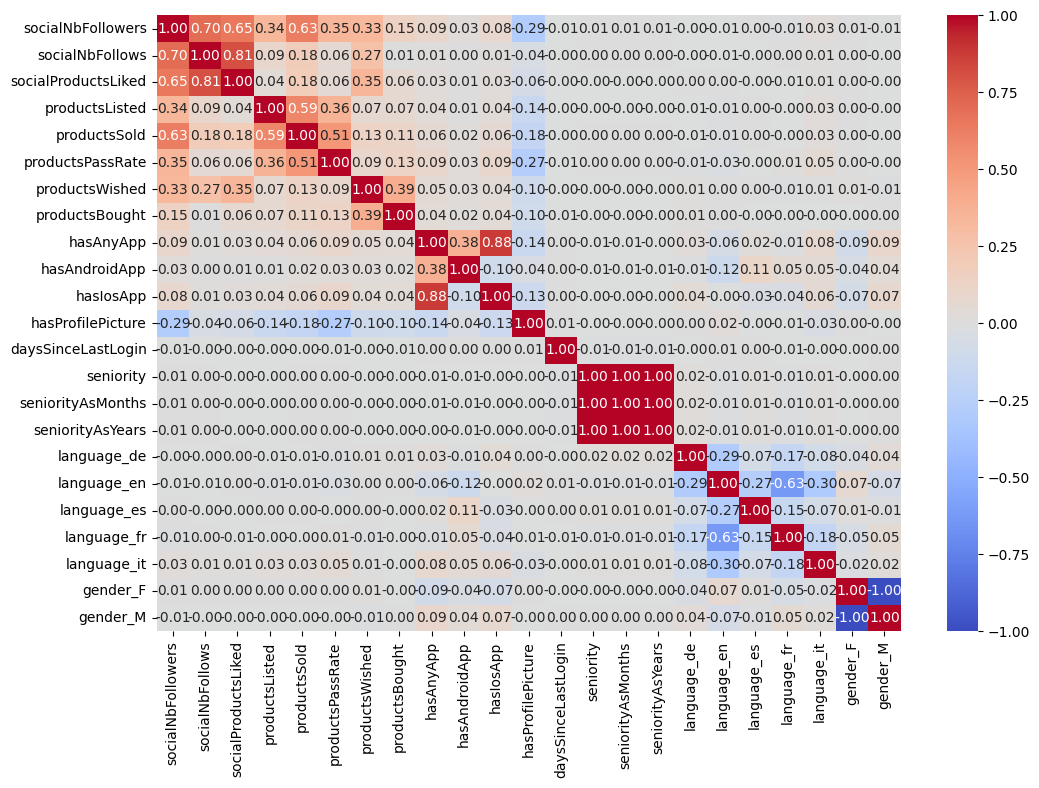

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(data_set[num_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()


### Brisanje kolona

In [ ]:
data_set = data_set.drop(columns=['seniority'])
data_set = data_set.drop(columns=['seniorityAsMonths'])
data_set.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98913 entries, 0 to 98912
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   socialNbFollowers    98913 non-null  int64  
 1   socialNbFollows      98913 non-null  int64  
 2   socialProductsLiked  98913 non-null  int64  
 3   productsListed       98913 non-null  int64  
 4   productsSold         98913 non-null  int64  
 5   productsPassRate     98913 non-null  float64
 6   productsWished       98913 non-null  int64  
 7   productsBought       98913 non-null  int64  
 8   hasAnyApp            98913 non-null  int64  
 9   hasAndroidApp        98913 non-null  int64  
 10  hasIosApp            98913 non-null  int64  
 11  hasProfilePicture    98913 non-null  int64  
 12  daysSinceLastLogin   98913 non-null  int64  
 13  seniorityAsYears     98913 non-null  float64
 14  language_de          98913 non-null  float64
 15  language_en          98913 non-null 

## Čišćenje outliera

In [ ]:
import pandas as pd
import numpy as np

df_clean = data_set.copy()

num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns

print("Original size:", len(df_clean))

for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df_clean = df_clean[(df_clean[col] >= lower) & 
                        (df_clean[col] <= upper)]

print("After IQR:", len(df_clean))

Original size: 98913
After IQR: 27846


## Skaliranje

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

data_scaled = scaler.fit_transform(df_clean[num_cols])
data_scaled_original = scaler.fit_transform(data_set[num_cols])

# Klasterizacija podataka

## K-Means

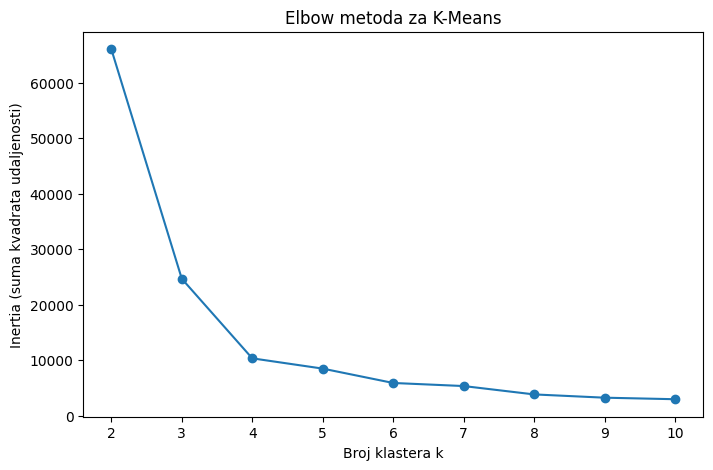

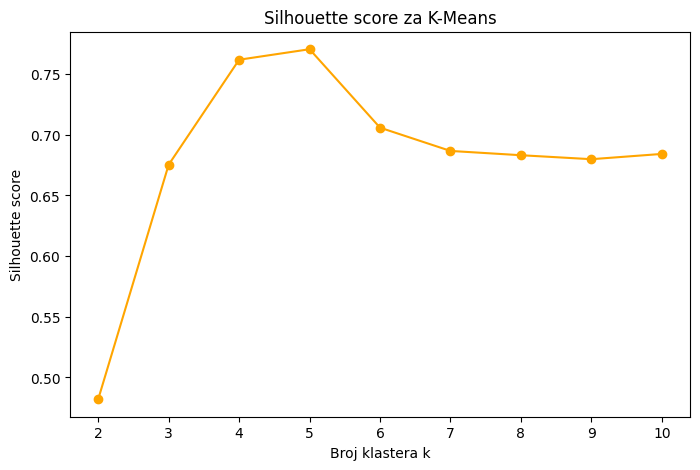

K-Means (clean dataset) Silhouette: 0.6753861105852818


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
K_range = range(2, 11) 

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow metoda za K-Means")
plt.xlabel("Broj klastera k")
plt.ylabel("Inertia (suma kvadrata udaljenosti)")
plt.show()


sil_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(data_scaled)
    score = silhouette_score(data_scaled, labels)
    sil_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(K_range, sil_scores, marker='o', color='orange')
plt.title("Silhouette score za K-Means")
plt.xlabel("Broj klastera k")
plt.ylabel("Silhouette score")
plt.show()


# Primer sa optimalnim k (recimo k=3)
kmeans = KMeans(n_clusters=5, random_state=42)
labels_kmeans = kmeans.fit_predict(data_scaled)
score_kmeans = silhouette_score(data_scaled, labels_kmeans)
print("K-Means (clean dataset) Silhouette:", score_kmeans)

U okviru rada izvršena je analiza podataka primenom K-Means algoritma klasterovanja. Optimalan broj klastera određen je korišćenjem Elbow metode i Silhouette koeficijenta. Uočeno je da se nakon vrednosti k = 4 smanjuje značaj pada inercije, dok Silhouette analiza pokazuje maksimalnu vrednost za k = 5.

Na osnovu dobijenih rezultata zaključeno je da je model sa pet klastera optimalan, jer obezbeđuje dobru kompaktnost unutar klastera i jasnu razdvojenost između njih. Rezultati ukazuju na postojanje jasno definisane strukture u podacima.

## Agglomerative Clustering

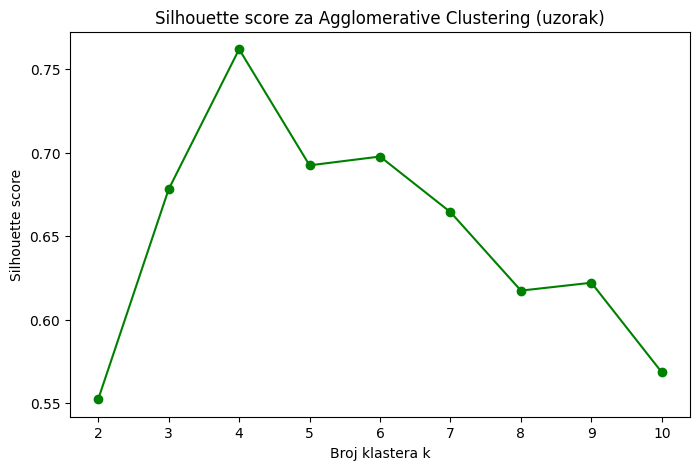

Agglomerative (uzorak) Silhouette: 0.6780775518468752


In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# Uzmi uzorak iz velikog dataset-a (npr. 5000 redova)
sample_size = 5000
if len(data_scaled) > sample_size:
    idx = np.random.choice(len(data_scaled), sample_size, replace=False)
    data_sample = data_scaled[idx]
else:
    data_sample = data_scaled

K_range = range(2, 11)
sil_scores_agglo = []

for k in K_range:
    agglo = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = agglo.fit_predict(data_sample)
    score = silhouette_score(data_sample, labels)
    sil_scores_agglo.append(score)


plt.figure(figsize=(8,5))
plt.plot(K_range, sil_scores_agglo, marker='o', color='green')
plt.title("Silhouette score za Agglomerative Clustering (uzorak)")
plt.xlabel("Broj klastera k")
plt.ylabel("Silhouette score")
plt.show()

# Primer sa odabranim k=4 na uzorku
agglo = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_agglo = agglo.fit_predict(data_sample)
score_agglo = silhouette_score(data_sample, labels_agglo)
print("Agglomerative (uzorak) Silhouette:", score_agglo)

Optimalan broj klastera je k = 4, jer daje najveću vrednost Silhouette koeficijenta i najbolje razdvajanje podataka.

## DBSCAN

In [ ]:
from sklearn.cluster import DBSCAN

# Clean dataset
dbscan = DBSCAN(eps=2, min_samples=5)
labels_dbscan = dbscan.fit_predict(data_scaled)

mask = labels_dbscan != -1  
score_dbscan = silhouette_score(data_scaled[mask], labels_dbscan[mask]) if sum(mask)>0 else None
print("DBSCAN (clean dataset) Silhouette:", score_dbscan)

# Original dataset sa outlierima
dbscan_orig = DBSCAN(eps=2, min_samples=5)
labels_dbscan_orig = dbscan_orig.fit_predict(data_scaled_original)

mask_orig = labels_dbscan_orig != -1
score_dbscan_orig = silhouette_score(data_scaled_original[mask_orig], labels_dbscan_orig[mask_orig]) if sum(mask_orig)>0 else None
print("DBSCAN (original dataset) Silhouette:", score_dbscan_orig)

In [ ]:
from sklearn.cluster import DBSCAN
import numpy as np

eps_values = np.arange(0.5, 5.1, 0.5)
sil_scores_dbscan = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(data_scaled)
    mask = labels != -1
    if sum(mask) > 0:
        score = silhouette_score(data_scaled[mask], labels[mask])
        sil_scores_dbscan.append(score)
    else:
        sil_scores_dbscan.append(np.nan)  # ako svi budu outlieri

# Graf
plt.figure(figsize=(8,5))
plt.plot(eps_values, sil_scores_dbscan, marker='o', color='red')
plt.title("Silhouette score za DBSCAN")
plt.xlabel("eps")
plt.ylabel("Silhouette score")
plt.show()

# Primer za eps=2
dbscan = DBSCAN(eps=2, min_samples=5)
labels_dbscan = dbscan.fit_predict(data_scaled)
mask = labels_dbscan != -1
score_dbscan = silhouette_score(data_scaled[mask], labels_dbscan[mask]) if sum(mask) > 0 else None
print("DBSCAN (clean dataset) Silhouette:", score_dbscan)

NameError: name 'data_scaled' is not defined

## Poređenje rezultata

In [ ]:
results = {
    "K-Means (clean)": score_kmeans,
    "Agglomerative (clean)": score_agglo,
    "DBSCAN (clean)": score_dbscan,
    "DBSCAN (original)": score_dbscan_orig
}

results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Silhouette Score'])
results_df = results_df.sort_values(by='Silhouette Score', ascending=False)
print(results_df)

NameError: name 'score_kmeans' is not defined